Extracting dataset...
Download and extraction complete.

Dataset classes:
rock: 726 images
paper: 712 images
scissors: 750 images

Class paths:
rock → /content/rps_kaggle/rock
paper → /content/rps_kaggle/paper
scissors → /content/rps_kaggle/scissors


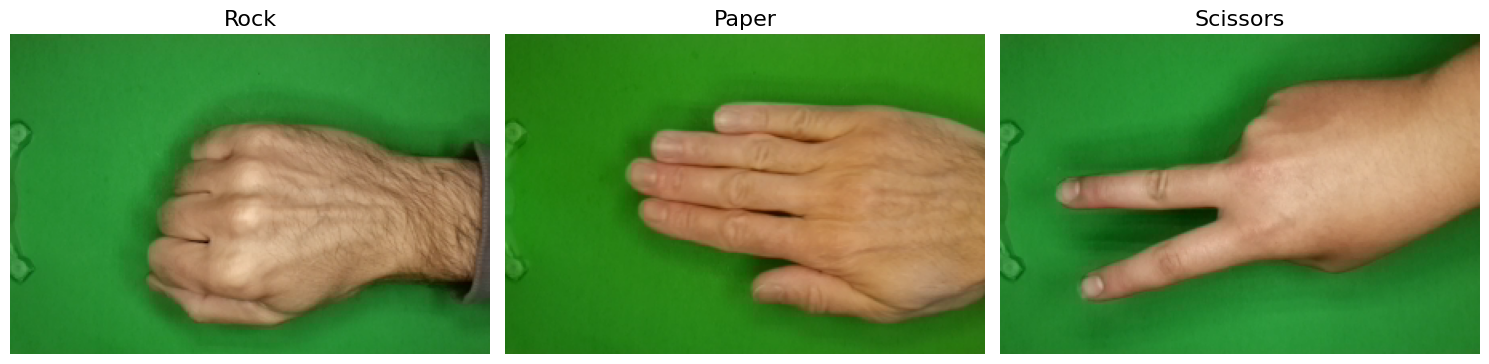

In [1]:
import os
import zipfile
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

dataset_url = "https://www.kaggle.com/api/v1/datasets/download/drgfreeman/rockpaperscissors"
zip_path = "/content/rps_kaggle.zip"
extract_path = Path("/content/rps_kaggle")

if not extract_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)

    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

    print("Download and extraction complete.")
else:
    print("Dataset already exists.")

class_dirs = {}

for root, dirs, files in os.walk(extract_path):
    folder = os.path.basename(root).lower()

    if folder in ["rock", "paper", "scissors"]:
        image_files = [
            f for f in files
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        if len(image_files) > 0:
            class_dirs[folder] = Path(root)

print("\nDataset classes:")

for class_name in ["rock", "paper", "scissors"]:
    if class_name in class_dirs:
        count = len([
            f for f in class_dirs[class_name].iterdir()
            if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ])
        print(f"{class_name}: {count} images")
    else:
        print(f"{class_name}: NOT FOUND")

print("\nClass paths:")

for class_name, path in class_dirs.items():
    print(class_name, "→", path)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

for i, class_name in enumerate(
    ["rock", "paper", "scissors"]
):

    if class_name not in class_dirs:
        axes[i].set_title(f"{class_name}: NOT FOUND")
        axes[i].axis("off")
        continue

    image_files = [
        f for f in class_dirs[class_name].iterdir()
        if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    image_path = image_files[
        len(image_files) // 2
    ]

    image = Image.open(
        image_path
    ).convert("RGB")

    axes[i].imshow(image)
    axes[i].set_title(
        class_name.capitalize(),
        fontsize=16
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

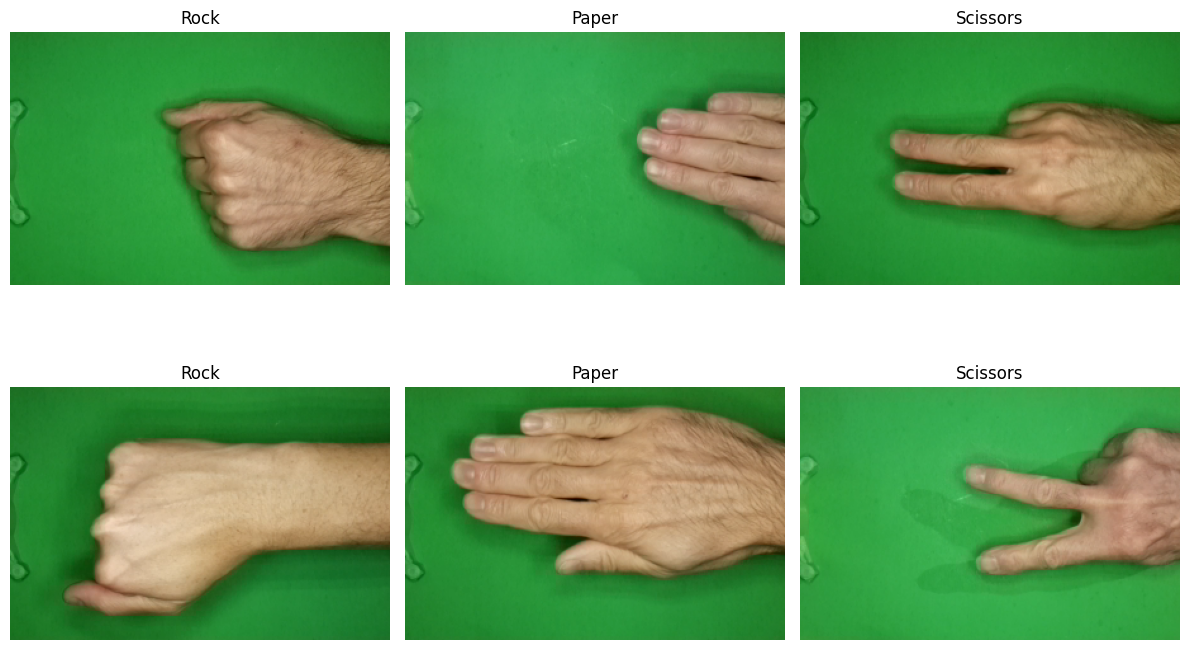

In [2]:
import random
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8)
)

for column, class_name in enumerate(
    ["rock", "paper", "scissors"]
):

    image_files = [
        f for f in class_dirs[class_name].iterdir()
        if f.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png"
        ]
    ]

    selected_images = random.sample(
        image_files,
        2
    )

    for row, image_path in enumerate(
        selected_images
    ):

        image = Image.open(
            image_path
        ).convert("RGB")

        axes[row, column].imshow(image)

        axes[row, column].set_title(
            class_name.capitalize()
        )

        axes[row, column].axis("off")

plt.tight_layout()
plt.show()

In [3]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

IMAGE_SIZE = 64
BATCH_SIZE = 64

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

dataset = datasets.ImageFolder(
    root="/content/rps_kaggle",
    transform=train_transform
)

print("Classes:", dataset.classes)
print("Class mapping:", dataset.class_to_idx)
print("Total images:", len(dataset))

train_size = int(len(dataset) * 0.70)
validation_size = int(len(dataset) * 0.15)
test_size = len(dataset) - train_size - validation_size

generator = torch.Generator().manual_seed(42)

train_dataset, validation_dataset, test_dataset = random_split(
    dataset,
    [train_size, validation_size, test_size],
    generator=generator
)

train_dataset.dataset.transform = train_transform
validation_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("\nDataset split:")
print("Training:", len(train_dataset))
print("Validation:", len(validation_dataset))
print("Testing:", len(test_dataset))

images, labels = next(iter(train_loader))

print("\nBatch shape:", images.shape)
print("Labels shape:", labels.shape)

Classes: ['paper', 'rock', 'rps-cv-images', 'scissors']
Class mapping: {'paper': 0, 'rock': 1, 'rps-cv-images': 2, 'scissors': 3}
Total images: 4376

Dataset split:
Training: 3063
Validation: 656
Testing: 657

Batch shape: torch.Size([64, 3, 64, 64])
Labels shape: torch.Size([64])


In [4]:
from pathlib import Path
import shutil
import os

SOURCE_PATH = Path("/content/rps_kaggle")
CLEAN_PATH = Path("/content/rps_clean")

if CLEAN_PATH.exists():
    shutil.rmtree(CLEAN_PATH)

CLEAN_PATH.mkdir(parents=True, exist_ok=True)

class_names = ["paper", "rock", "scissors"]

for class_name in class_names:

    destination = CLEAN_PATH / class_name
    destination.mkdir(parents=True, exist_ok=True)

    found = []

    for path in SOURCE_PATH.rglob("*"):

        if (
            path.is_file()
            and path.suffix.lower() in [".jpg", ".jpeg", ".png"]
            and path.parent.name.lower() == class_name
        ):
            found.append(path)

    seen_names = set()

    for image_path in found:

        filename = image_path.name

        if filename in seen_names:
            continue

        seen_names.add(filename)

        shutil.copy2(
            image_path,
            destination / filename
        )

    print(
        f"{class_name}: "
        f"{len(list(destination.iterdir()))} images"
    )

print("\nClean dataset created at:")
print(CLEAN_PATH)

paper: 712 images
rock: 726 images
scissors: 750 images

Clean dataset created at:
/content/rps_clean


In [5]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

IMAGE_SIZE = 64
BATCH_SIZE = 64

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

dataset = datasets.ImageFolder(
    root="/content/rps_clean",
    transform=train_transform
)

print("Classes:", dataset.classes)
print("Class mapping:", dataset.class_to_idx)
print("Total images:", len(dataset))

train_size = int(len(dataset) * 0.70)
validation_size = int(len(dataset) * 0.15)
test_size = len(dataset) - train_size - validation_size

generator = torch.Generator().manual_seed(42)

train_dataset, validation_dataset, test_dataset = random_split(
    dataset,
    [train_size, validation_size, test_size],
    generator=generator
)

train_dataset.dataset.transform = train_transform
validation_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("\nDataset split:")
print("Training:", len(train_dataset))
print("Validation:", len(validation_dataset))
print("Testing:", len(test_dataset))

images, labels = next(iter(train_loader))

print("\nBatch shape:", images.shape)
print("Labels shape:", labels.shape)

Classes: ['paper', 'rock', 'scissors']
Class mapping: {'paper': 0, 'rock': 1, 'scissors': 2}
Total images: 2188

Dataset split:
Training: 1531
Validation: 328
Testing: 329

Batch shape: torch.Size([64, 3, 64, 64])
Labels shape: torch.Size([64])


In [6]:
import torch
import torch.nn as nn

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

class CNN(nn.Module):

    def __init__(self, num_classes=3):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            )
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 8 * 8,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


model = CNN(
    num_classes=len(dataset.classes)
).to(device)

print(model)
print("\nDevice:", device)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=3, bias=True)
  )
)

Device: cpu


In [7]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([64, 3, 64, 64])
Output shape: torch.Size([64, 3])


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

NUM_EPOCHS = 15
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

train_losses = []
validation_losses = []

train_accuracies = []
validation_accuracies = []

best_validation_accuracy = 0.0

MODEL_PATH = "/content/RPS/model/rps_cnn.pth"

import os
os.makedirs("/content/RPS/model", exist_ok=True)

for epoch in range(NUM_EPOCHS):

    model.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_train_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        total_train += labels.size(0)

        correct_train += (
            predictions == labels
        ).sum().item()

    train_loss = (
        running_train_loss /
        total_train
    )

    train_accuracy = (
        correct_train /
        total_train
    )

    model.eval()

    running_validation_loss = 0.0
    correct_validation = 0
    total_validation = 0

    with torch.no_grad():

        for images, labels in validation_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_validation_loss += (
                loss.item() * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            total_validation += labels.size(0)

            correct_validation += (
                predictions == labels
            ).sum().item()

    validation_loss = (
        running_validation_loss /
        total_validation
    )

    validation_accuracy = (
        correct_validation /
        total_validation
    )

    train_losses.append(
        train_loss
    )

    validation_losses.append(
        validation_loss
    )

    train_accuracies.append(
        train_accuracy
    )

    validation_accuracies.append(
        validation_accuracy
    )

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy * 100:.2f}% "
        f"Val Loss: {validation_loss:.4f} "
        f"Val Acc: {validation_accuracy * 100:.2f}%"
    )

    if validation_accuracy > best_validation_accuracy:

        best_validation_accuracy = validation_accuracy

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )

        print(
            f"Best model saved: "
            f"{best_validation_accuracy * 100:.2f}%"
        )

print("\nTraining completed.")
print("Best validation accuracy:",
      f"{best_validation_accuracy * 100:.2f}%")
print("Model saved to:", MODEL_PATH)

Epoch [1/15] Train Loss: 0.7568 Train Acc: 67.47% Val Loss: 0.3080 Val Acc: 90.24%
Best model saved: 90.24%
Epoch [2/15] Train Loss: 0.1896 Train Acc: 93.01% Val Loss: 0.1421 Val Acc: 95.43%
Best model saved: 95.43%
Epoch [3/15] Train Loss: 0.0750 Train Acc: 97.71% Val Loss: 0.0885 Val Acc: 97.87%
Best model saved: 97.87%
Epoch [4/15] Train Loss: 0.0582 Train Acc: 97.98% Val Loss: 0.0550 Val Acc: 97.87%
Epoch [5/15] Train Loss: 0.0281 Train Acc: 99.02% Val Loss: 0.0649 Val Acc: 97.87%
Epoch [6/15] Train Loss: 0.0282 Train Acc: 99.02% Val Loss: 0.0603 Val Acc: 97.87%
Epoch [7/15] Train Loss: 0.0150 Train Acc: 99.41% Val Loss: 0.0532 Val Acc: 98.17%
Best model saved: 98.17%
Epoch [8/15] Train Loss: 0.0065 Train Acc: 99.87% Val Loss: 0.0433 Val Acc: 99.09%
Best model saved: 99.09%
Epoch [9/15] Train Loss: 0.0053 Train Acc: 99.80% Val Loss: 0.0406 Val Acc: 99.39%
Best model saved: 99.39%
Epoch [10/15] Train Loss: 0.0045 Train Acc: 99.93% Val Loss: 0.0413 Val Acc: 99.39%
Epoch [11/15] Train

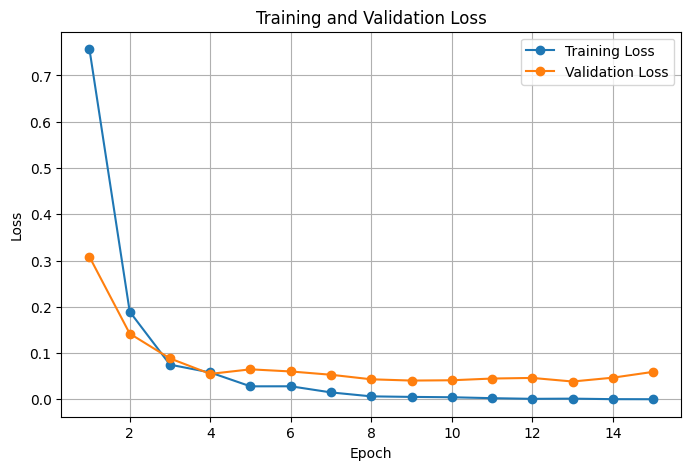

In [9]:
import matplotlib.pyplot as plt

epochs = range(
    1,
    NUM_EPOCHS + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

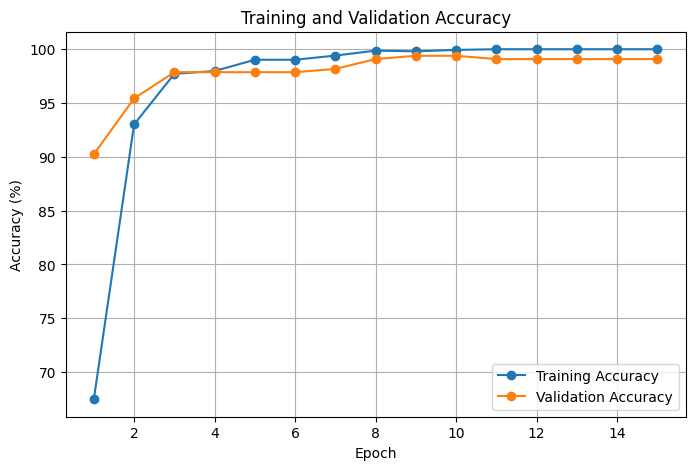

In [11]:
import numpy as np
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    np.array(train_accuracies) * 100,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    np.array(validation_accuracies) * 100,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [12]:
import torch

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best model loaded successfully.")
print(
    f"Best validation accuracy: "
    f"{best_validation_accuracy * 100:.2f}%"
)

Best model loaded successfully.
Best validation accuracy: 99.39%


In [13]:
test_loss = 0.0
correct = 0
total = 0

all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        test_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

test_loss = test_loss / total
test_accuracy = correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Images: {total}")

Test Loss: 0.0140
Test Accuracy: 99.39%
Test Images: 329


In [14]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=dataset.classes
    )
)

              precision    recall  f1-score   support

       paper       0.99      0.99      0.99       125
        rock       0.99      0.99      0.99        99
    scissors       1.00      1.00      1.00       105

    accuracy                           0.99       329
   macro avg       0.99      0.99      0.99       329
weighted avg       0.99      0.99      0.99       329



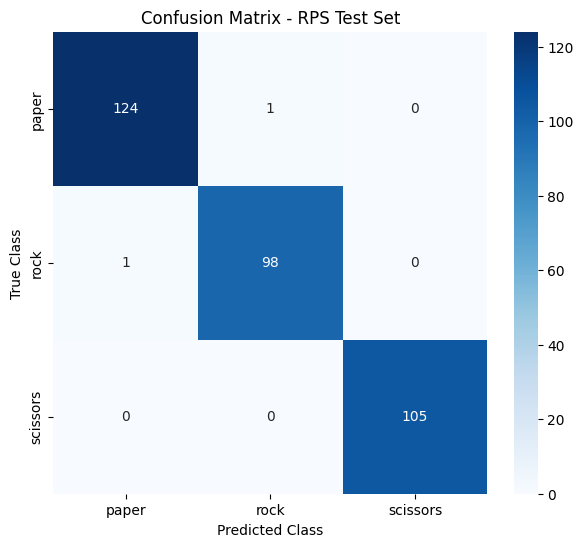

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix - RPS Test Set")

plt.show()

In [16]:
import numpy as np

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

incorrect_indices = np.where(
    all_labels != all_predictions
)[0]

print(
    "Total incorrect predictions:",
    len(incorrect_indices)
)

Total incorrect predictions: 2


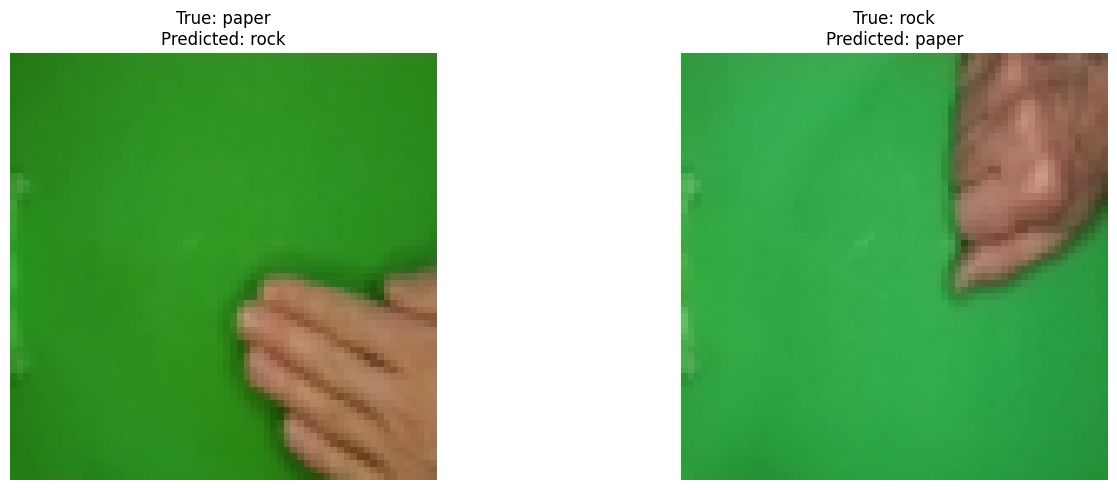

In [17]:
import random
import matplotlib.pyplot as plt
import numpy as np

if len(incorrect_indices) == 0:

    print("The model classified every test image correctly.")

else:

    selected_indices = random.sample(
        list(incorrect_indices),
        min(3, len(incorrect_indices))
    )

    fig, axes = plt.subplots(
        1,
        len(selected_indices),
        figsize=(15, 5)
    )

    if len(selected_indices) == 1:
        axes = [axes]

    for ax, index in zip(
        axes,
        selected_indices
    ):

        image, true_label = test_dataset[index]

        image = image.permute(
            1,
            2,
            0
        ).numpy()

        image = (
            image * np.array(STD)
            + np.array(MEAN)
        )

        image = np.clip(
            image,
            0,
            1
        )

        predicted_label = all_predictions[index]

        ax.imshow(image)

        ax.set_title(
            f"True: {dataset.classes[true_label]}\n"
            f"Predicted: {dataset.classes[predicted_label]}"
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [19]:
import shutil
from pathlib import Path

REPO_PATH = Path("/content/RPS")

if REPO_PATH.exists():
    shutil.rmtree(REPO_PATH)

!git clone https://github.com/Naimur125/RPS.git /content/RPS

CUSTOM_DATA_DIR = REPO_PATH / "dataset"

custom_images = sorted([
    f for f in CUSTOM_DATA_DIR.iterdir()
    if f.is_file()
    and f.suffix.lower() in [".jpg", ".jpeg", ".png"]
])

print("Custom image folder:", CUSTOM_DATA_DIR)
print("Number of custom images:", len(custom_images))

for image_path in custom_images:
    print(image_path.name)

Cloning into '/content/RPS'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 20 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 965.51 KiB | 4.11 MiB/s, done.
Custom image folder: /content/RPS/dataset
Number of custom images: 10
paper_01.jpeg
paper_02.jpeg
paper_03.jpeg
rock_01.jpeg
rock_02.jpeg
rock_03.jpeg
scissor_01.jpeg
scissor_02.jpeg
scissor_03.jpeg
scissor_04.jpeg


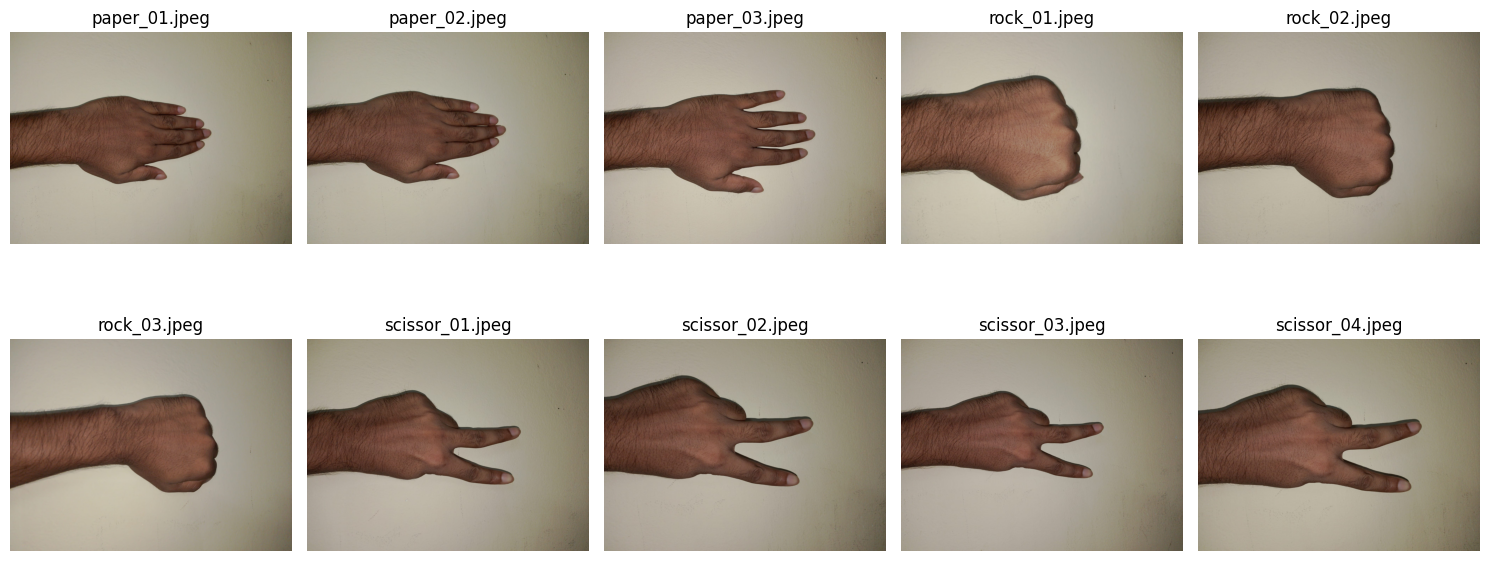

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

columns = 5
rows = 2

fig, axes = plt.subplots(
    rows,
    columns,
    figsize=(15, 7)
)

axes = axes.flatten()

for ax, image_path in zip(
    axes,
    custom_images
):

    image = Image.open(
        image_path
    ).convert("RGB")

    ax.imshow(image)

    ax.set_title(
        image_path.name
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [21]:
import torch
from PIL import Image

def predict_custom_image(image_path):

    image = Image.open(
        image_path
    ).convert("RGB")

    image_tensor = test_transform(
        image
    )

    image_tensor = image_tensor.unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        output = model(image_tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

    predicted_class = dataset.classes[
        prediction.item()
    ]

    confidence_percentage = (
        confidence.item() * 100
    )

    return (
        predicted_class,
        confidence_percentage,
        probabilities[0].cpu().numpy()
    )


custom_results = []

for image_path in custom_images:

    predicted_class, confidence, probabilities = (
        predict_custom_image(image_path)
    )

    custom_results.append({
        "filename": image_path.name,
        "predicted_class": predicted_class,
        "confidence": confidence,
        "probabilities": probabilities
    })

    print(
        f"{image_path.name} → "
        f"{predicted_class.capitalize()} "
        f"({confidence:.2f}%)"
    )

paper_01.jpeg → Scissors (99.83%)
paper_02.jpeg → Scissors (99.74%)
paper_03.jpeg → Paper (98.37%)
rock_01.jpeg → Paper (99.95%)
rock_02.jpeg → Scissors (79.91%)
rock_03.jpeg → Scissors (63.95%)
scissor_01.jpeg → Scissors (94.67%)
scissor_02.jpeg → Scissors (99.10%)
scissor_03.jpeg → Scissors (96.38%)
scissor_04.jpeg → Scissors (96.79%)


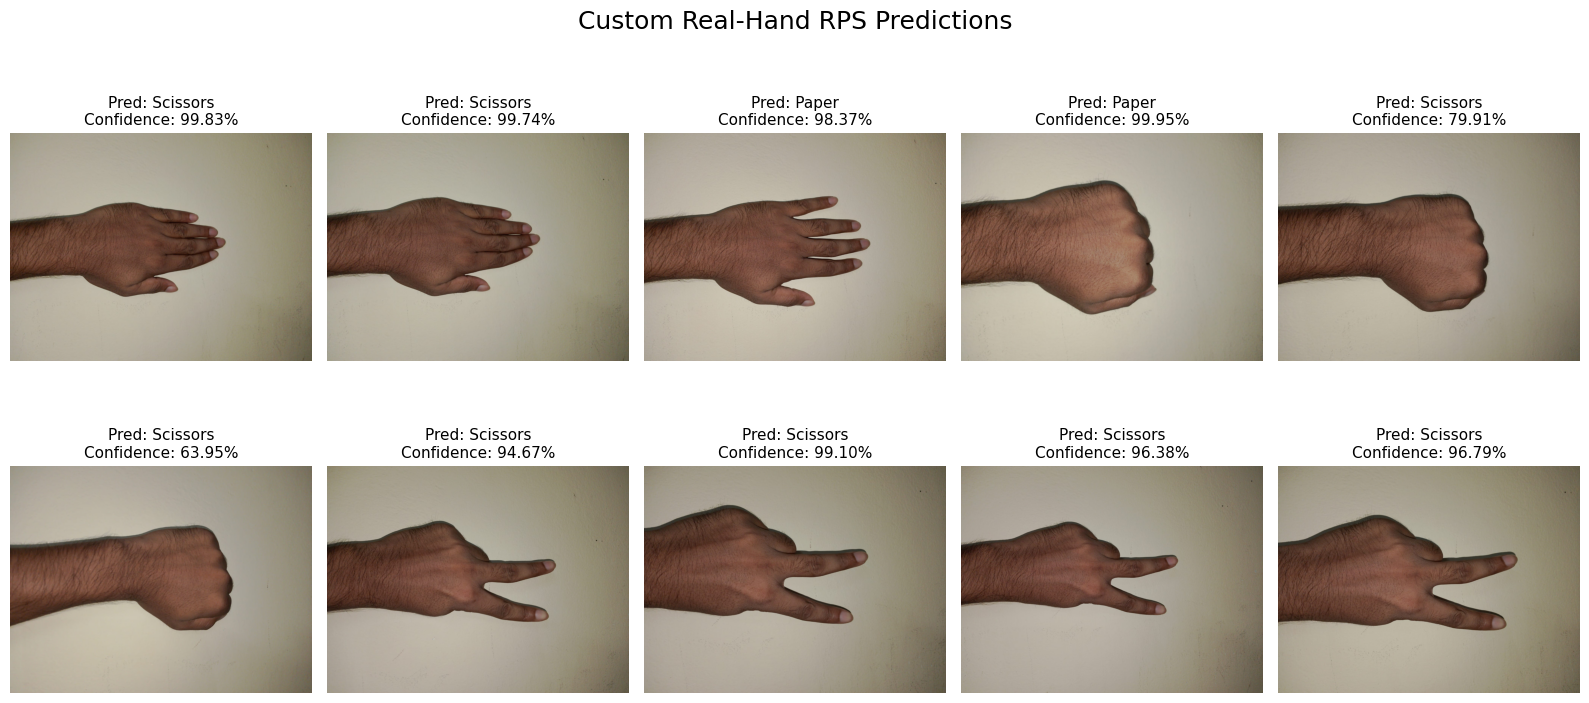

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

columns = 5
rows = 2

fig, axes = plt.subplots(
    rows,
    columns,
    figsize=(16, 8)
)

axes = axes.flatten()

for ax, result in zip(
    axes,
    custom_results
):

    image_path = (
        CUSTOM_DATA_DIR /
        result["filename"]
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    ax.imshow(image)

    ax.set_title(
        f"Pred: {result['predicted_class'].capitalize()}\n"
        f"Confidence: {result['confidence']:.2f}%",
        fontsize=11
    )

    ax.axis("off")

plt.suptitle(
    "Custom Real-Hand RPS Predictions",
    fontsize=18
)

plt.tight_layout()
plt.show()

In [23]:
true_labels = []
predicted_labels = []

for result in custom_results:

    filename = result["filename"].lower()

    if filename.startswith("paper"):
        true_class = "paper"

    elif filename.startswith("rock"):
        true_class = "rock"

    elif filename.startswith("scissor"):
        true_class = "scissors"

    else:
        true_class = None

    true_labels.append(true_class)
    predicted_labels.append(
        result["predicted_class"]
    )

correct = sum(
    true == predicted
    for true, predicted in zip(
        true_labels,
        predicted_labels
    )
)

custom_accuracy = (
    correct /
    len(true_labels)
) * 100

print(
    f"Custom Image Accuracy: "
    f"{custom_accuracy:.2f}%"
)

print(
    f"Correct: {correct}/{len(true_labels)}"
)

Custom Image Accuracy: 50.00%
Correct: 5/10
